# 08: X2 — DFN replication of v0.1 DC-AC batch (MJ1 frequencies)

## Goal

Replicate v0.1's 30-case DC-AC superimposed charging batch using **DFN** model on Chen2020,
keeping all other variables identical to v0.1 SPMe baseline. Single variable changed: model order.

## Why

v0.1 reported 48% sign-agreement on Δt(Q80) using SPMe + Chen2020 + MJ1-derived frequencies (τ=11.1s).
Two non-separable hypotheses remained:

1. **Cell-physics**: SPMe lacks AC-acceleration mechanism (P2D dynamics absent)
2. **Frequency-mismatch**: Chen2020's intrinsic τ ≠ MJ1's, MJ1-derived frequency grid mis-targeted

X2 isolates hypothesis 1: if DFN closes the sign-agreement gap, P2D mechanism is the missing piece.
X4 (separate notebook) will isolate hypothesis 2 by changing frequency grid.

## Methodology

- **Model**: `pybamm.lithium_ion.DFN(options={"thermal": "lumped"})`  ← changed from SPMe
- **Parameters**: Chen2020 (LG M50, 5.0 Ah)  ← unchanged from v0.1
- **Solver**: PyBaMM default (CasadiSolver)  ← unchanged from v0.1
- **Protocol**: 5-phase: CC dis to 2.5V → CV C/136 → 3805s rest → DC+AC CC to 4.2V → CV C/68
- **Frequencies**: τ=11.1s reference (MJ1) → 0.1τ, 1τ, 10τ → unchanged from v0.1
- **30 cases**: same as v0.1 batch (DC ∈ {0.2, 0.3, 0.4, 0.9}C × AC ∈ {0.1, 0.2, 0.3, 0.7, 0.8}C × 3 frequencies + DC baselines)

## Expected wall-clock

DFN ~5-10× slower than SPMe. v0.1 SPMe batch was 23.3s for 30 cases.
X2 DFN estimated: 2-5 minutes total.

## Today's deliverable

- 30-case DFN batch results (CSV)
- Δt(Q80) table comparing X2 (DFN) vs v0.1 (SPMe)
- Sign-agreement analysis
- **No conclusions yet** — wait for X4 before drawing inference about hypotheses

In [1]:
# ============================================================
# X2 Cell A: Calibrate DFN Phase 0 + 1 timing for Chen2020
# (replaces v0.1's SPMe-based t_phase2_start_s = 8118.5)
# ============================================================
import pybamm
import numpy as np
import time

# Build minimal experiment for Phase 0a + 0b + 1 only
calib_experiment = pybamm.Experiment([
    "Discharge at 1C until 2.5V",
    "Hold at 2.5V until C/136",
    "Rest for 3805 seconds",
])

calib_model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
calib_pv = pybamm.ParameterValues("Chen2020")
calib_pv["Ambient temperature [K]"] = 20.0 + 273.15
calib_pv["Initial temperature [K]"] = 20.0 + 273.15

calib_sim = pybamm.Simulation(calib_model, parameter_values=calib_pv, experiment=calib_experiment)

print("Running DFN Phase 0+1 calibration...")
t0 = time.time()
calib_sol = calib_sim.solve()
calib_wall = time.time() - t0

# Extract phase boundaries
print(f"\n=== DFN Phase 0+1 calibration result ===")
print(f"Wall-clock: {calib_wall:.1f} s")
print(f"\nStep boundaries:")
phase_durations = []
for i, cyc in enumerate(calib_sol.cycles):
    t_start_cyc = float(cyc.t[0])
    t_end_cyc = float(cyc.t[-1])
    duration = t_end_cyc - t_start_cyc
    phase_durations.append(duration)
    name = ["Phase 0a (CC dis to 2.5V)", "Phase 0b (CV at 2.5V to C/136)", "Phase 1 (Rest 3805s)"][i]
    print(f"  {name}: [{t_start_cyc:.1f}, {t_end_cyc:.1f}] s  (Δt = {duration:.1f} s)")

t_phase2_start_s_DFN = float(calib_sol.cycles[-1].t[-1])
print(f"\n*** DFN t_phase2_start_s = {t_phase2_start_s_DFN:.1f} s ***")
print(f"v0.1 SPMe t_phase2_start_s = 8118.5 s")
print(f"Δ (DFN - SPMe) = {t_phase2_start_s_DFN - 8118.5:+.1f} s")

# Sanity check on key state at end of Phase 1
T_end_K = float(calib_sol["X-averaged cell temperature [K]"].entries[-1])
V_end_V = float(calib_sol["Voltage [V]"].entries[-1])
print(f"\nAt end of Phase 1:")
print(f"  V = {V_end_V:.4f} V (expected ~2.5V from CV cutoff and equilibration)")
print(f"  T = {T_end_K - 273.15:.2f} °C (expected close to 20°C ambient after long rest)")

Running DFN Phase 0+1 calibration...

=== DFN Phase 0+1 calibration result ===
Wall-clock: 0.6 s

Step boundaries:
  Phase 0a (CC dis to 2.5V): [0.0, 3560.2] s  (Δt = 3560.2 s)
  Phase 0b (CV at 2.5V to C/136): [3560.2, 4313.8] s  (Δt = 753.6 s)
  Phase 1 (Rest 3805s): [4313.8, 8118.8] s  (Δt = 3805.0 s)

*** DFN t_phase2_start_s = 8118.8 s ***
v0.1 SPMe t_phase2_start_s = 8118.5 s
Δ (DFN - SPMe) = +0.3 s

At end of Phase 1:
  V = 2.5124 V (expected ~2.5V from CV cutoff and equilibration)
  T = 20.04 °C (expected close to 20°C ambient after long rest)


In [2]:
# ============================================================
# Cell 3: run_single_case_DFN — DFN version of v0.1's batch function
# Single change vs v0.1 Cell 8 (patched version): SPMe → DFN
# Keeps infeasibility handling, sign convention, schema identical for direct comparison.
# ============================================================
import pybamm
import numpy as np
from scipy.integrate import cumulative_trapezoid
import time


def run_single_case_DFN(
    I_DC_Crate: float,
    A_Crate: float,
    f_Hz: float,
    parameter_set: str = "Chen2020",
    T_ambient_C: float = 20.0,
    nominal_capacity_Ah: float = 5.0,
    t_phase2_start_s: float = 8118.5,   # use v0.1 value; DFN diff is 0.3s, negligible
    verbose: bool = False,
) -> dict:
    """DFN version of v0.1 run_single_case. Identical schema, identical protocol."""
    
    # Sanitize inputs
    if A_Crate is None or (isinstance(A_Crate, float) and np.isnan(A_Crate)):
        A_Crate = 0.0
    if f_Hz is None or (isinstance(f_Hz, float) and np.isnan(f_Hz)):
        f_Hz = 0.0
    
    I_DC_A = -abs(I_DC_Crate) * nominal_capacity_Ah
    A_A    = A_Crate * nominal_capacity_Ah
    kappa  = (A_Crate / abs(I_DC_Crate)) if abs(I_DC_Crate) > 1e-9 else 0.0
    
    if A_Crate < 1e-9:
        case_id = f"DC{abs(I_DC_Crate):.2f}C_baseline"
    else:
        case_id = f"DC{abs(I_DC_Crate):.2f}C+AC{A_Crate:.2f}C_f{f_Hz:.5f}Hz"
    
    # Build current function
    def dc_ac_current(variables):
        t_absolute = variables["Time [s]"]
        t_relative = t_absolute - t_phase2_start_s
        return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge",
        description=f"Phase 2: {case_id}",
    )
    experiment = pybamm.Experiment([
        "Discharge at 1C until 2.5V",
        "Hold at 2.5V until C/136",
        "Rest for 3805 seconds",
        dcac_step,
        "Hold at 4.2V until C/68",
    ])
    
    # ===== ONLY DIFFERENCE FROM v0.1: SPMe → DFN =====
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    
    pv = pybamm.ParameterValues(parameter_set)
    pv["Ambient temperature [K]"] = T_ambient_C + 273.15
    pv["Initial temperature [K]"] = T_ambient_C + 273.15
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    
    t_start = time.time()
    try:
        solution = sim.solve()
    except Exception as e:
        return {
            "case_id": case_id, "I_DC_Crate": abs(I_DC_Crate), "A_Crate": A_Crate, "f_Hz": f_Hz,
            "kappa": kappa, "wall_clock_s": time.time() - t_start,
            "status": f"FAILED_SOLVE: {type(e).__name__}: {e}",
        }
    wall_clock_s = time.time() - t_start
    
    # Detect infeasibility
    n_cycles = len(solution.cycles)
    expected_cycles = 5
    
    base_dict = {
        "case_id": case_id, "I_DC_Crate": abs(I_DC_Crate), "A_Crate": A_Crate, "f_Hz": f_Hz,
        "kappa": kappa, "wall_clock_s": wall_clock_s,
    }
    
    if n_cycles < 4:
        return {**base_dict, "status": f"INFEASIBLE_EARLY: only {n_cycles} cycles completed"}
    
    if n_cycles < expected_cycles:
        phase2_partial = solution.cycles[3]
        cc_time_partial_s = phase2_partial.t[-1] - phase2_partial.t[0]
        T_max_partial = float(phase2_partial["X-averaged cell temperature [K]"].entries.max() - 273.15)
        V_min_phase2 = float(phase2_partial["Terminal voltage [V]"].entries.min())
        
        if verbose:
            print(f"  [{case_id}] INFEASIBLE: Phase 2 hit Min V ({V_min_phase2:.3f}V). "
                  f"Partial CC={cc_time_partial_s/60:.2f}min")
        
        return {
            **base_dict,
            "status": f"INFEASIBLE_MIN_V: V_min={V_min_phase2:.3f}V in Phase 2",
            "CC_time_s_partial": cc_time_partial_s,
            "T_max_charging_C_partial": T_max_partial,
            "V_min_phase2": V_min_phase2,
        }
    
    # Normal case (5 cycles complete)
    phase2 = solution.cycles[3]
    phase3 = solution.cycles[4]
    
    cc_time_s = phase2.t[-1] - phase2.t[0]
    cv_time_s = phase3.t[-1] - phase3.t[0]
    total_time_s = cc_time_s + cv_time_s
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, unique_idx = np.unique(t_chg, return_index=True)
    unique_idx_sorted = np.sort(unique_idx)
    t_chg = t_chg[unique_idx_sorted]
    I_chg = I_chg[unique_idx_sorted]
    t_chg = t_chg - t_chg[0]
    
    Q_net_As = -cumulative_trapezoid(I_chg, t_chg, initial=0)
    Q_net_mAh = Q_net_As / 3600.0 * 1000.0
    Q_final_mAh = float(Q_net_mAh[-1])
    
    dQ = np.diff(Q_net_mAh)
    n_decreases = int(np.sum(dQ < 0))
    pct_decreases = 100.0 * n_decreases / max(len(dQ), 1)
    
    T_max_p2 = float(phase2["X-averaged cell temperature [K]"].entries.max() - 273.15)
    T_max_p3 = float(phase3["X-averaged cell temperature [K]"].entries.max() - 273.15)
    T_max_charging = max(T_max_p2, T_max_p3)
    
    if verbose:
        print(f"  [{case_id}] CC={cc_time_s/60:.2f}min, CV={cv_time_s/60:.2f}min, "
              f"T_max={T_max_charging:.2f}°C, Q_net={Q_final_mAh:.0f}mAh, "
              f"AC reversal={pct_decreases:.1f}%, wall={wall_clock_s:.2f}s")
    
    return {
        **base_dict,
        "CC_time_s": cc_time_s, "CV_time_s": cv_time_s, "total_time_s": total_time_s,
        "CC_time_min": cc_time_s/60, "CV_time_min": cv_time_s/60, "total_time_min": total_time_s/60,
        "Q_net_final_mAh": Q_final_mAh,
        "Q_net_trajectory": Q_net_mAh.tolist(),
        "t_chg": t_chg.tolist(),
        "I_chg": I_chg.tolist(),
        "T_max_charging_C": T_max_charging,
        "n_AC_reversals_steps": n_decreases,
        "pct_AC_reversals": pct_decreases,
        "status": "ok",
    }

print("✓ run_single_case_DFN defined.")
print("  Only difference vs v0.1 (SPMe): model = pybamm.lithium_ion.DFN")

✓ run_single_case_DFN defined.
  Only difference vs v0.1 (SPMe): model = pybamm.lithium_ion.DFN


In [3]:
# ============================================================
# Cell 4: Single-case validation — DC 0.3C baseline (no AC)
# Purpose: confirm DFN runs the v0.1 protocol without errors before batch
# Reference: v0.1 SPMe DC 0.3C baseline (from data/results_day6_summary.csv if available)
# ============================================================

print("=" * 70)
print("Single-case validation: DFN + Chen2020 + DC 0.3C baseline (no AC)")
print("=" * 70)

result_test = run_single_case_DFN(
    I_DC_Crate=0.3,
    A_Crate=0.0,           # DC baseline (no AC)
    f_Hz=0.0,
    parameter_set="Chen2020",
    T_ambient_C=20.0,
    nominal_capacity_Ah=5.0,
    t_phase2_start_s=8118.5,
    verbose=True,
)

print(f"\n=== DFN baseline result ===")
for k, v in result_test.items():
    if k in ["Q_net_trajectory", "t_chg", "I_chg"]:
        if isinstance(v, list):
            print(f"  {k}: <list of {len(v)} elements>")
        else:
            print(f"  {k}: {v}")
    else:
        print(f"  {k}: {v}")

# Compare key metrics to v0.1 SPMe baseline (from memory of Day 6)
# v0.1 DC 0.3C SPMe baseline expectation:
#   CC time ~3-4 hours, CV time ~30-60 min, Q_net ~5126 mAh
print(f"\n=== Quick sanity check ===")
print(f"DFN result:")
print(f"  CC_time = {result_test.get('CC_time_min', 'N/A'):.2f} min" if 'CC_time_min' in result_test else "  CC_time: missing")
print(f"  CV_time = {result_test.get('CV_time_min', 'N/A'):.2f} min" if 'CV_time_min' in result_test else "  CV_time: missing")
print(f"  Q_net   = {result_test.get('Q_net_final_mAh', 'N/A'):.0f} mAh" if 'Q_net_final_mAh' in result_test else "  Q_net: missing")
print(f"  T_max   = {result_test.get('T_max_charging_C', 'N/A'):.2f} °C" if 'T_max_charging_C' in result_test else "  T_max: missing")
print(f"  Wall-clock = {result_test.get('wall_clock_s', 'N/A'):.1f} s")

print(f"\nv0.1 SPMe DC 0.3C baseline (Day 6 reference):")
print(f"  CC_time ~ 200 min")
print(f"  CV_time ~ 30-50 min")
print(f"  Q_net ~ 5126 mAh")
print(f"  T_max ~ 20-22 °C (1C charge mild self-heating)")

Single-case validation: DFN + Chen2020 + DC 0.3C baseline (no AC)
  [DC0.30C_baseline] CC=189.09min, CV=55.26min, T_max=21.95°C, Q_net=5126mAh, AC reversal=0.0%, wall=1.07s

=== DFN baseline result ===
  case_id: DC0.30C_baseline
  I_DC_Crate: 0.3
  A_Crate: 0.0
  f_Hz: 0.0
  kappa: 0.0
  wall_clock_s: 1.0688209533691406
  CC_time_s: 11345.449198764976
  CV_time_s: 3315.7676974956994
  total_time_s: 14661.216896260676
  CC_time_min: 189.09081997941627
  CV_time_min: 55.26279495826166
  total_time_min: 244.35361493767792
  Q_net_final_mAh: 5125.988242972963
  Q_net_trajectory: <list of 235 elements>
  t_chg: <list of 235 elements>
  I_chg: <list of 235 elements>
  T_max_charging_C: 21.954979483666364
  n_AC_reversals_steps: 0
  pct_AC_reversals: 0.0
  status: ok

=== Quick sanity check ===
DFN result:
  CC_time = 189.09 min
  CV_time = 55.26 min
  Q_net   = 5126 mAh
  T_max   = 21.95 °C
  Wall-clock = 1.1 s

v0.1 SPMe DC 0.3C baseline (Day 6 reference):
  CC_time ~ 200 min
  CV_time ~ 3

In [5]:
# ============================================================
# Cell 5: X2 batch — Run all v0.1 cases under DFN
# Cases reconstructed from data/results_day6_summary.csv (v0.1 SPMe results)
# Single change vs v0.1: SPMe → DFN. Everything else identical.
# ============================================================
import pandas as pd
import time

# === Load v0.1 case configurations ===
df_v01 = pd.read_csv("../data/results_day6_summary.csv")
v01_cases = df_v01[["condition", "I_DC_C", "A_C", "f_Hz"]].copy()
print(f"Loaded {len(v01_cases)} cases from v0.1 CSV")
print(f"\nFirst 5 cases:")
print(v01_cases.head().to_string(index=False))

# Add the missing infeasible case from v0.1 (0.2+0.8C 10τ hit Min V)
# This was excluded from v0.1 CSV but is part of the original 30-case design
infeasible_case_row = pd.DataFrame({
    "condition": ["0.2+0.8C 10τ"],
    "I_DC_C": [0.2],
    "A_C": [0.8],
    "f_Hz": [0.00143],   # 10τ precise value
})
v01_cases = pd.concat([v01_cases, infeasible_case_row], ignore_index=True)
print(f"\nAdded back infeasible case: 0.2+0.8C 10τ. Total cases: {len(v01_cases)}")

# === Run X2 batch (DFN) ===
print("\n" + "=" * 70)
print(f"X2 batch: {len(v01_cases)} cases × DFN + Chen2020 + MJ1 frequencies")
print("=" * 70)

x2_results = []
batch_t_start = time.time()
n_ok = 0
n_infeas = 0
n_fail = 0

for i, row in v01_cases.iterrows():
    condition = row["condition"]
    I_DC = row["I_DC_C"]
    A = row["A_C"]
    f = row["f_Hz"]
    
    print(f"[{i+1:2d}/{len(v01_cases)}] {condition:25s} (DC={I_DC:.2f}, AC={A:.2f}, f={f:.5f}Hz)... ",
          end="", flush=True)
    
    r = run_single_case_DFN(
        I_DC_Crate=I_DC,
        A_Crate=A,
        f_Hz=f,
        parameter_set="Chen2020",
        T_ambient_C=20.0,
        nominal_capacity_Ah=5.0,
        t_phase2_start_s=8118.5,
        verbose=False,
    )
    r["condition"] = condition  # preserve v0.1 condition label for matching
    x2_results.append(r)
    
    if r["status"] == "ok":
        n_ok += 1
        print(f"✓ CC={r['CC_time_min']:.1f}m T={r['T_max_charging_C']:.1f}°C "
              f"Q={r['Q_net_final_mAh']:.0f}mAh ({r['wall_clock_s']:.1f}s)")
    elif "INFEASIBLE" in r["status"]:
        n_infeas += 1
        print(f"⊘ INFEASIBLE ({r['wall_clock_s']:.1f}s)")
    else:
        n_fail += 1
        print(f"✗ FAILED: {r['status']}")

batch_total = time.time() - batch_t_start
print("\n" + "=" * 70)
print(f"X2 batch complete: {n_ok} ok, {n_infeas} infeasible, {n_fail} failed")
print(f"Total wall-clock: {batch_total:.1f}s ({batch_total/len(v01_cases):.2f} s/case)")
print("=" * 70)

# === Build DataFrame ===
df_x2 = pd.DataFrame(x2_results)

# Reorder key columns
front_cols = ["condition", "case_id", "I_DC_Crate", "A_Crate", "f_Hz", "kappa",
              "status",
              "CC_time_min", "CV_time_min", "total_time_min",
              "Q_net_final_mAh", "T_max_charging_C", "pct_AC_reversals",
              "wall_clock_s"]
front_cols = [c for c in front_cols if c in df_x2.columns]
other_cols = [c for c in df_x2.columns if c not in front_cols]
df_x2 = df_x2[front_cols + other_cols]

# Display summary (drop heavy trajectory columns for display)
display_cols = ["condition", "I_DC_Crate", "A_Crate", "f_Hz", "kappa",
                "status", "CC_time_min", "CV_time_min", "Q_net_final_mAh",
                "T_max_charging_C", "wall_clock_s"]
display_cols = [c for c in display_cols if c in df_x2.columns]

print("\n=== X2 batch summary ===")
with pd.option_context('display.float_format', '{:.3f}'.format,
                        'display.width', 200, 'display.max_columns', 20):
    print(df_x2[display_cols].to_string(index=False))

# === Save (drop heavy trajectory columns from CSV; keep them in df_x2 for later analysis) ===
df_x2_csv = df_x2.drop(columns=[c for c in ["Q_net_trajectory", "t_chg", "I_chg"] if c in df_x2.columns])
csv_out = "../data/results_day8_x2_dfn_mj1freq.csv"
df_x2_csv.to_csv(csv_out, index=False)
print(f"\nSaved: {csv_out}")

Loaded 30 cases from v0.1 CSV

First 5 cases:
     condition  I_DC_C  A_C  f_Hz
   0.1+0.9C 1τ     0.1  0.9 0.014
   0.1+0.2C 1τ     0.1  0.2 0.014
   0.2+0.3C 1τ     0.2  0.3 0.014
  0.2+0.3C 10τ     0.2  0.3 0.001
0.2+0.3C 34.8τ     0.2  0.3 0.000

Added back infeasible case: 0.2+0.8C 10τ. Total cases: 31

X2 batch: 31 cases × DFN + Chen2020 + MJ1 frequencies
[ 1/31] 0.1+0.9C 1τ               (DC=0.10, AC=0.90, f=0.01400Hz)... ✓ CC=498.5m T=26.6°C Q=5126mAh (12.4s)
[ 2/31] 0.1+0.2C 1τ               (DC=0.10, AC=0.20, f=0.01400Hz)... ✓ CC=583.0m T=20.8°C Q=5128mAh (5.2s)
[ 3/31] 0.2+0.3C 1τ               (DC=0.20, AC=0.30, f=0.01400Hz)... ✓ CC=277.1m T=21.9°C Q=5126mAh (4.0s)
[ 4/31] 0.2+0.3C 10τ              (DC=0.20, AC=0.30, f=0.00100Hz)... ✓ CC=277.9m T=22.4°C Q=5127mAh (1.3s)
[ 5/31] 0.2+0.3C 34.8τ            (DC=0.20, AC=0.30, f=0.00000Hz)... ✓ CC=291.9m T=21.0°C Q=5126mAh (1.0s)
[ 6/31] 0.2+0.8C 0.1τ             (DC=0.20, AC=0.80, f=0.14300Hz)... ✓ CC=248.9m T=25.3°C Q=5124mAh 

2026-04-27 12:15:40.572 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00100Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (0.8s)
[ 9/31] 0.3+0.7C 0.1τ             (DC=0.30, AC=0.70, f=0.14300Hz)... ✓ CC=162.7m T=25.1°C Q=5125mAh (34.7s)
[10/31] 0.3+0.7C 1τ               (DC=0.30, AC=0.70, f=0.01400Hz)... ✓ CC=160.4m T=25.3°C Q=5124mAh (3.8s)
[11/31] 0.3+0.7C 10τ              (DC=0.30, AC=0.70, f=0.00100Hz)... 

2026-04-27 12:16:20.267 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.30C+AC0.70C_f0.00100Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (0.8s)
[12/31] 0.3+0.4C 0.1τ             (DC=0.30, AC=0.40, f=0.14300Hz)... ✓ CC=170.1m T=23.5°C Q=5128mAh (25.7s)
[13/31] 0.3+0.4C 1τ               (DC=0.30, AC=0.40, f=0.01400Hz)... ✓ CC=168.7m T=23.6°C Q=5126mAh (3.1s)
[14/31] 0.3+0.4C 10τ              (DC=0.30, AC=0.40, f=0.00100Hz)... ✓ CC=162.9m T=24.4°C Q=5125mAh (1.5s)
[15/31] 0.4+0.6C 0.5τ             (DC=0.40, AC=0.60, f=0.02900Hz)... ✓ CC=118.8m T=25.4°C Q=5124mAh (5.4s)
[16/31] 0.4+0.5C 1.67τ            (DC=0.40, AC=0.50, f=0.00900Hz)... ✓ CC=119.8m T=25.1°C Q=5124mAh (2.1s)
[17/31] 0.4+0.6C 1.67τ            (DC=0.40, AC=0.60, f=0.00900Hz)... ✓ CC=118.0m T=25.6°C Q=5125mAh (2.4s)
[18/31] 0.4+0.6C 5τ               (DC=0.40, AC=0.60, f=0.00300Hz)... ✓ CC=115.2m T=26.2°C Q=5126mAh (1.3s)
[19/31] 0.4+0.6C 10τ              (DC=0.40, AC=0.60, f=0.00100Hz)... ✓ CC=113.3m T=27.2°C Q=5127mAh (1.1s)
[20/31] 0.5+0.5C 1τ               (DC=0.50, AC=0.50, f=0.01400Hz)... ✓ CC=93.7m T=26.0°C Q=5125mAh (2.2s)
[21/31] 0.9+0.1C 

2026-04-27 12:17:18.537 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00143Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (1.0s)

X2 batch complete: 28 ok, 3 infeasible, 0 failed
Total wall-clock: 191.0s (6.16 s/case)

=== X2 batch summary ===
     condition  I_DC_Crate  A_Crate  f_Hz  kappa                                    status  CC_time_min  CV_time_min  Q_net_final_mAh  T_max_charging_C  wall_clock_s
   0.1+0.9C 1τ       0.100    0.900 0.014  9.000                                        ok      498.544       69.996         5126.109            26.591        12.399
   0.1+0.2C 1τ       0.100    0.200 0.014  2.000                                        ok      583.046       47.563         5127.879            20.790         5.205
   0.2+0.3C 1τ       0.200    0.300 0.014  1.500                                        ok      277.071       58.887         5126.488            21.876         4.033
  0.2+0.3C 10τ       0.200    0.300 0.001  1.500                                        ok      277.904       61.514         5126.961            22.389         1.312
0.2+0.3C 34.8τ       0.200    0.300

In [6]:
# X2 Cell 6: Inspect what data is needed for Δt(Q80) comparison
import pandas as pd

# Check what columns v0.1 CSV has
df_v01_csv = pd.read_csv("../data/results_day6_summary.csv")
print("v0.1 CSV columns:")
print(df_v01_csv.columns.tolist())
print()
print("Δt(Q80)-related columns:")
dt_cols = [c for c in df_v01_csv.columns if "Δt" in c or "delta" in c.lower() or "Q80" in c]
print(dt_cols)
print()
print("Sample row (with Δt columns):")
print(df_v01_csv[["condition", "I_DC_C", "A_C", "f_Hz"] + dt_cols].head(10).to_string(index=False))

v0.1 CSV columns:
['condition', 'I_DC_C', 'A_C', 'f_Hz', 'kappa', 'sim_CC_min', 'sim_CV_min', 'sim_total_min', 'sim_T_max_C', 'sim_Q_mAh', 'exp_T_max_C', 'exp_Δt_Q80', 'exp_total_min', 'AC_rev_pct', 'wall_s', 'status']

Δt(Q80)-related columns:
['exp_Δt_Q80']

Sample row (with Δt columns):
     condition  I_DC_C  A_C  f_Hz  exp_Δt_Q80
   0.1+0.9C 1τ     0.1  0.9 0.014        2.88
   0.1+0.2C 1τ     0.1  0.2 0.014        0.59
   0.2+0.3C 1τ     0.2  0.3 0.014        0.17
  0.2+0.3C 10τ     0.2  0.3 0.001        5.05
0.2+0.3C 34.8τ     0.2  0.3 0.000       15.03
 0.2+0.8C 0.1τ     0.2  0.8 0.143        1.26
   0.2+0.8C 1τ     0.2  0.8 0.014        3.77
  0.2+0.8C 10τ     0.2  0.8 0.001       15.31
 0.3+0.7C 0.1τ     0.3  0.7 0.143        0.02
   0.3+0.7C 1τ     0.3  0.7 0.014        2.97


In [7]:
import os
import pandas as pd
data_dir = "../data"
print("Files in ../data/:")
for f in sorted(os.listdir(data_dir)):
    fp = os.path.join(data_dir, f)
    size_kb = os.path.getsize(fp) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

Files in ../data/:
  figure1_master_table_cleaned.csv  (7.4 KB)
  results_day6_batch_scan.json  (9869.3 KB)
  results_day6_summary.csv  (3.4 KB)
  results_day8_stage2_hppc_chen2020.csv  (12.0 KB)
  results_day8_x2_dfn_mj1freq.csv  (7.7 KB)


In [8]:
# X2 Cell 7: Inspect v0.1 batch JSON to find SPMe trajectories
import json

with open("../data/results_day6_batch_scan.json", "r") as f:
    v01_json = json.load(f)

# Top-level structure check
if isinstance(v01_json, list):
    print(f"JSON is a list with {len(v01_json)} entries")
    print(f"First entry keys: {list(v01_json[0].keys())}")
    print()
    # Check if trajectory data is there
    first = v01_json[0]
    has_traj = "Q_net_trajectory" in first
    has_time = "t_chg" in first
    print(f"Has Q_net_trajectory: {has_traj}")
    print(f"Has t_chg: {has_time}")
    if has_traj:
        traj = first["Q_net_trajectory"]
        print(f"Q_net_trajectory length (first case): {len(traj)}")
        print(f"Q range: {min(traj):.0f} to {max(traj):.0f} mAh")
elif isinstance(v01_json, dict):
    print(f"JSON is a dict with keys: {list(v01_json.keys())[:10]}")
else:
    print(f"JSON is type: {type(v01_json)}")

# Sample first 2 cases identifiers
if isinstance(v01_json, list) and len(v01_json) > 1:
    print(f"\nFirst 2 case identifiers:")
    for entry in v01_json[:2]:
        print(f"  {entry.get('case_id', 'no case_id')}: "
              f"DC={entry.get('I_DC_Crate', '?')}, "
              f"AC={entry.get('A_Crate', '?')}, "
              f"f={entry.get('f_Hz', '?')}, "
              f"status={entry.get('status', '?')}")

JSON is a list with 30 entries
First entry keys: ['case_id', 'I_DC_Crate', 'A_Crate', 'f_Hz', 'kappa', 'wall_clock_s', 'CC_time_s', 'CV_time_s', 'total_time_s', 'CC_time_min', 'CV_time_min', 'total_time_min', 'Q_net_final_mAh', 'Q_net_trajectory', 't_chg', 'I_chg', 'T_max_charging_C', 'n_AC_reversals_steps', 'pct_AC_reversals', 'status', 'exp_T_max_C', 'exp_Delta_t_Q80_min', 'exp_total_time_min', 'condition_label', 'DC_base_label']

Has Q_net_trajectory: True
Has t_chg: True
Q_net_trajectory length (first case): 13700
Q range: -23 to 5126 mAh

First 2 case identifiers:
  DC0.10C+AC0.90C_f0.01430Hz: DC=0.1, AC=0.9, f=0.0143, status=ok
  DC0.10C+AC0.20C_f0.01430Hz: DC=0.1, AC=0.2, f=0.0143, status=ok


In [9]:
# ============================================================
# Cell 8: Rebuild X2 cases from v0.1 JSON (precise frequencies)
# Discovered v0.1 used 5-decimal precision (e.g. 0.01430 Hz, 0.00143 Hz)
# but CSV truncated to 3 decimals (0.014, 0.001) — a 30% error at 10τ
# Reload cases from JSON case_id strings to get exact frequencies
# ============================================================
import re

# Extract precise (DC, AC, f) from v0.1 JSON
cases_precise = []
for entry in v01_json:
    cid = entry["case_id"]
    
    # Pattern: "DC0.10C+AC0.90C_f0.01430Hz" or "DC0.30C_baseline"
    if "_baseline" in cid:
        m = re.match(r"DC([\d.]+)C_baseline", cid)
        if m:
            cases_precise.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": float(m.group(1)),
                "A_C": 0.0,
                "f_Hz": 0.0,
                "tau_label": "baseline",
            })
    else:
        m = re.match(r"DC([\d.]+)C\+AC([\d.]+)C_f([\d.]+)Hz", cid)
        if m:
            cases_precise.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": float(m.group(1)),
                "A_C": float(m.group(2)),
                "f_Hz": float(m.group(3)),
                "tau_label": entry.get("condition_label", "").split()[-1] if entry.get("condition_label") else "?",
            })
        else:
            print(f"⚠ Could not parse case_id: {cid}")

df_cases_precise = pd.DataFrame(cases_precise)
print(f"Reconstructed {len(df_cases_precise)} cases with precise frequencies")
print(f"\nUnique frequencies (sorted):")
unique_f = sorted(df_cases_precise["f_Hz"].unique())
print(unique_f)

# Compare to CSV-derived (truncated) frequencies
print(f"\nFrequency precision comparison (CSV vs JSON case_id):")
df_csv = pd.read_csv("../data/results_day6_summary.csv")
df_compare = df_cases_precise.merge(
    df_csv[["condition", "f_Hz"]].rename(columns={"f_Hz": "f_Hz_csv"}),
    on="condition", how="left"
)
df_compare["f_diff_pct"] = ((df_compare["f_Hz"] - df_compare["f_Hz_csv"]) / df_compare["f_Hz"] * 100).where(df_compare["f_Hz"] > 0)
diff_cases = df_compare[df_compare["f_diff_pct"].abs() > 5].sort_values("f_diff_pct", key=abs, ascending=False)
print(f"\nCases with >5% frequency error from CSV truncation:")
print(diff_cases[["condition", "f_Hz", "f_Hz_csv", "f_diff_pct"]].to_string(index=False))

Reconstructed 30 cases with precise frequencies

Unique frequencies (sorted):
[np.float64(0.0), np.float64(0.00041), np.float64(0.00086), np.float64(0.00143), np.float64(0.00286), np.float64(0.0086), np.float64(0.0143), np.float64(0.0286), np.float64(0.143)]

Frequency precision comparison (CSV vs JSON case_id):

Cases with >5% frequency error from CSV truncation:
     condition    f_Hz  f_Hz_csv  f_diff_pct
0.2+0.3C 34.8τ 0.00041     0.000   100.00000
  0.2+0.3C 10τ 0.00143     0.001    30.06993
  0.2+0.8C 10τ 0.00143     0.001    30.06993
  0.3+0.7C 10τ 0.00143     0.001    30.06993
  0.3+0.4C 10τ 0.00143     0.001    30.06993
  0.4+0.6C 10τ 0.00143     0.001    30.06993
  0.9+0.1C 10τ 0.00143     0.001    30.06993
0.9+0.1C 16.7τ 0.00086     0.001   -16.27907


In [10]:
# ============================================================
# Cell 9: Re-run X2 batch with precise frequencies from v0.1 JSON case_ids
# Replaces the truncated-CSV-based first run
# ============================================================
import time

# Build cases list with precise frequencies
cases_for_x2 = df_cases_precise.copy()

# Add the infeasible case (0.2+0.8C 10τ) that v0.1 dropped from JSON
# but is part of the original 30-case design
infeasible_row = pd.DataFrame({
    "condition": ["0.2+0.8C 10τ"],
    "I_DC_C": [0.2],
    "A_C": [0.8],
    "f_Hz": [0.00143],   # precise 10τ value
    "tau_label": ["10τ"],
})
cases_for_x2 = pd.concat([cases_for_x2, infeasible_row], ignore_index=True)

print(f"X2 re-run with precise frequencies: {len(cases_for_x2)} cases")
print(f"Frequencies range: {cases_for_x2['f_Hz'].min():.5f} to {cases_for_x2['f_Hz'].max():.5f} Hz")

print("\n" + "=" * 70)
print(f"X2 batch RE-RUN — precise frequencies")
print("=" * 70)

x2_results_v2 = []
batch_t_start = time.time()
n_ok = 0
n_infeas = 0
n_fail = 0

for i, row in cases_for_x2.iterrows():
    condition = row["condition"]
    I_DC = row["I_DC_C"]
    A = row["A_C"]
    f = row["f_Hz"]
    
    print(f"[{i+1:2d}/{len(cases_for_x2)}] {condition:25s} (DC={I_DC:.2f}, AC={A:.2f}, f={f:.5f}Hz)... ",
          end="", flush=True)
    
    r = run_single_case_DFN(
        I_DC_Crate=I_DC,
        A_Crate=A,
        f_Hz=f,
        parameter_set="Chen2020",
        T_ambient_C=20.0,
        nominal_capacity_Ah=5.0,
        t_phase2_start_s=8118.5,
        verbose=False,
    )
    r["condition"] = condition
    r["tau_label"] = row["tau_label"]
    x2_results_v2.append(r)
    
    if r["status"] == "ok":
        n_ok += 1
        print(f"✓ CC={r['CC_time_min']:.1f}m T={r['T_max_charging_C']:.1f}°C "
              f"Q={r['Q_net_final_mAh']:.0f}mAh ({r['wall_clock_s']:.1f}s)")
    elif "INFEASIBLE" in r["status"]:
        n_infeas += 1
        print(f"⊘ INFEASIBLE ({r['wall_clock_s']:.1f}s)")
    else:
        n_fail += 1
        print(f"✗ FAILED: {r['status']}")

batch_total = time.time() - batch_t_start
print("\n" + "=" * 70)
print(f"X2 RE-RUN complete: {n_ok} ok, {n_infeas} infeasible, {n_fail} failed")
print(f"Total wall-clock: {batch_total:.1f}s ({batch_total/len(cases_for_x2):.2f} s/case)")
print("=" * 70)

# Build DataFrame
df_x2_v2 = pd.DataFrame(x2_results_v2)

# Save (drop heavy trajectory columns from CSV; keep them in df for later analysis)
df_x2_v2_csv = df_x2_v2.drop(
    columns=[c for c in ["Q_net_trajectory", "t_chg", "I_chg"] if c in df_x2_v2.columns]
)
csv_out = "../data/results_day8_x2_dfn_mj1freq_v2.csv"
df_x2_v2_csv.to_csv(csv_out, index=False)
print(f"\nSaved: {csv_out}")

# Save full data with trajectories as JSON for Δt(Q80) calculation
import json
json_out = "../data/results_day8_x2_dfn_mj1freq_v2.json"
with open(json_out, "w") as f:
    json.dump(x2_results_v2, f, default=str)
print(f"Saved: {json_out}")

X2 re-run with precise frequencies: 31 cases
Frequencies range: 0.00000 to 0.14300 Hz

X2 batch RE-RUN — precise frequencies
[ 1/31] 0.1+0.9C 1τ               (DC=0.10, AC=0.90, f=0.01430Hz)... ✓ CC=499.7m T=26.6°C Q=5127mAh (12.6s)
[ 2/31] 0.1+0.2C 1τ               (DC=0.10, AC=0.20, f=0.01430Hz)... ✓ CC=583.6m T=20.8°C Q=5128mAh (5.2s)
[ 3/31] 0.2+0.3C 1τ               (DC=0.20, AC=0.30, f=0.01430Hz)... ✓ CC=277.1m T=21.9°C Q=5126mAh (3.7s)
[ 4/31] 0.2+0.3C 10τ              (DC=0.20, AC=0.30, f=0.00143Hz)... ✓ CC=276.0m T=22.2°C Q=5128mAh (1.3s)
[ 5/31] 0.2+0.3C 34.8τ            (DC=0.20, AC=0.30, f=0.00041Hz)... ✓ CC=274.0m T=23.2°C Q=5128mAh (1.0s)
[ 6/31] 0.2+0.8C 0.1τ             (DC=0.20, AC=0.80, f=0.14300Hz)... ✓ CC=248.9m T=25.3°C Q=5124mAh (62.2s)
[ 7/31] 0.2+0.8C 1τ               (DC=0.20, AC=0.80, f=0.01430Hz)... ✓ CC=244.5m T=25.5°C Q=5125mAh (6.6s)
[ 8/31] 0.2+0.8C 10τ              (DC=0.20, AC=0.80, f=0.00143Hz)... 

2026-04-27 12:29:51.837 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00143Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (1.0s)
[ 9/31] 0.3+0.7C 0.1τ             (DC=0.30, AC=0.70, f=0.14300Hz)... ✓ CC=162.7m T=25.1°C Q=5125mAh (35.4s)
[10/31] 0.3+0.7C 1τ               (DC=0.30, AC=0.70, f=0.01430Hz)... ✓ CC=160.5m T=25.3°C Q=5123mAh (4.3s)
[11/31] 0.3+0.7C 10τ              (DC=0.30, AC=0.70, f=0.00143Hz)... ✓ CC=159.6m T=26.6°C Q=5125mAh (1.2s)
[12/31] 0.3+0.4C 0.1τ             (DC=0.30, AC=0.40, f=0.14300Hz)... ✓ CC=170.1m T=23.5°C Q=5128mAh (24.8s)
[13/31] 0.3+0.4C 1τ               (DC=0.30, AC=0.40, f=0.01430Hz)... ✓ CC=168.7m T=23.6°C Q=5126mAh (3.0s)
[14/31] 0.3+0.4C 10τ              (DC=0.30, AC=0.40, f=0.00143Hz)... ✓ CC=170.8m T=23.8°C Q=5128mAh (1.3s)
[15/31] 0.4+0.6C 0.5τ             (DC=0.40, AC=0.60, f=0.02860Hz)... ✓ CC=119.3m T=25.4°C Q=5124mAh (4.9s)
[16/31] 0.4+0.5C 1.67τ            (DC=0.40, AC=0.50, f=0.00860Hz)... ✓ CC=119.6m T=25.1°C Q=5125mAh (2.1s)
[17/31] 0.4+0.6C 1.67τ            (DC=0.40, AC=0.60, f=0.00860Hz)... ✓ CC=117.7m T=25.7°C Q=5124mAh (2.1s)
[18/31] 0.4+0.6

2026-04-27 12:31:28.330 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00143Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (1.0s)

X2 RE-RUN complete: 29 ok, 2 infeasible, 0 failed
Total wall-clock: 190.4s (6.14 s/case)

Saved: ../data/results_day8_x2_dfn_mj1freq_v2.csv
Saved: ../data/results_day8_x2_dfn_mj1freq_v2.json


In [11]:
# ============================================================
# Cell 10: Δt(Q80) computation + sign-agreement matrix
# Three-way comparison: X2 (DFN sim) vs v0.1 (SPMe sim) vs MJ1 (experiment)
# ============================================================
import json
import pandas as pd
import numpy as np

# Helper: Δt(Q80) from a Q_net trajectory + matching DC baseline trajectory
def compute_dt_at_Q(t_chg, Q_net_mAh, t_chg_baseline, Q_net_baseline_mAh, Q_target_mAh):
    """First-passage time when Q_net first reaches Q_target.
       Δt = t_baseline(Q*) - t_protocol(Q*).  +Δt = AC accelerates."""
    def first_passage(t, Q):
        Q = np.asarray(Q)
        idx = np.where(Q >= Q_target_mAh)[0]
        if len(idx) == 0:
            return np.nan
        return float(t[int(idx[0])])
    
    t_proto = first_passage(np.asarray(t_chg), Q_net_mAh)
    t_base = first_passage(np.asarray(t_chg_baseline), Q_net_baseline_mAh)
    if np.isnan(t_proto) or np.isnan(t_base):
        return np.nan
    return (t_base - t_proto) / 60.0   # minutes

# === Build baseline lookup: DC_C → trajectory ===
# X2 baselines (DFN)
x2_baselines = {}
for r in x2_results_v2:
    if r["A_Crate"] < 1e-9 and r.get("status") == "ok":
        x2_baselines[float(r["I_DC_Crate"])] = (
            np.array(r["t_chg"]),
            np.array(r["Q_net_trajectory"]),
        )

# v0.1 baselines (SPMe) from JSON
v01_baselines = {}
for entry in v01_json:
    if entry["A_Crate"] < 1e-9 and entry.get("status") == "ok":
        v01_baselines[float(entry["I_DC_Crate"])] = (
            np.array(entry["t_chg"]),
            np.array(entry["Q_net_trajectory"]),
        )

print(f"X2 baselines available for DC: {sorted(x2_baselines.keys())}")
print(f"v0.1 baselines available for DC: {sorted(v01_baselines.keys())}")

Q80_TARGET = 0.80 * 5126.0   # 80% of nominal Chen2020 capacity = 4101 mAh

# === Build comparison DataFrame ===
comparison_rows = []
for r_x2 in x2_results_v2:
    if r_x2["A_Crate"] < 1e-9:
        continue   # skip baselines
    if r_x2.get("status") != "ok":
        continue   # skip infeasible
    
    DC = float(r_x2["I_DC_Crate"])
    AC = float(r_x2["A_Crate"])
    f = float(r_x2["f_Hz"])
    cond = r_x2["condition"]
    
    # Find matching v0.1 SPMe entry (same DC, AC, f within tolerance)
    v01_match = None
    for entry in v01_json:
        if entry.get("status") != "ok":
            continue
        if entry["A_Crate"] < 1e-9:
            continue
        if abs(float(entry["I_DC_Crate"]) - DC) < 1e-3 and \
           abs(float(entry["A_Crate"]) - AC) < 1e-3 and \
           abs(float(entry["f_Hz"]) - f) < 1e-5:
            v01_match = entry
            break
    
    # Compute Δt(Q80) — DFN
    dt_x2 = np.nan
    if DC in x2_baselines:
        t_base_x2, Q_base_x2 = x2_baselines[DC]
        dt_x2 = compute_dt_at_Q(
            np.array(r_x2["t_chg"]), np.array(r_x2["Q_net_trajectory"]),
            t_base_x2, Q_base_x2, Q80_TARGET,
        )
    
    # Compute Δt(Q80) — SPMe (v0.1)
    dt_v01 = np.nan
    if v01_match is not None and DC in v01_baselines:
        t_base_v01, Q_base_v01 = v01_baselines[DC]
        dt_v01 = compute_dt_at_Q(
            np.array(v01_match["t_chg"]), np.array(v01_match["Q_net_trajectory"]),
            t_base_v01, Q_base_v01, Q80_TARGET,
        )
    
    # Δt(Q80) — experiment (from CSV)
    dt_exp = np.nan
    csv_match = df_v01_csv[df_v01_csv["condition"] == cond]
    if len(csv_match) > 0 and pd.notna(csv_match["exp_Δt_Q80"].iloc[0]):
        dt_exp = float(csv_match["exp_Δt_Q80"].iloc[0])
    
    # Sign-agreement (any three-way comparison)
    def sign(x):
        if np.isnan(x): return None
        if x > 0.05: return "+"
        if x < -0.05: return "-"
        return "0"
    
    s_x2 = sign(dt_x2)
    s_v01 = sign(dt_v01)
    s_exp = sign(dt_exp)
    
    comparison_rows.append({
        "condition": cond,
        "DC": DC, "AC": AC, "f_Hz": f, "kappa": AC/DC,
        "tau_label": r_x2.get("tau_label", "?"),
        "dt_x2_DFN_min": dt_x2,
        "dt_v01_SPMe_min": dt_v01,
        "dt_exp_MJ1_min": dt_exp,
        "sign_x2": s_x2, "sign_v01": s_v01, "sign_exp": s_exp,
        "x2_vs_exp": (s_x2 == s_exp) if (s_x2 and s_exp) else None,
        "v01_vs_exp": (s_v01 == s_exp) if (s_v01 and s_exp) else None,
        "x2_vs_v01": (s_x2 == s_v01) if (s_x2 and s_v01) else None,
    })

df_compare = pd.DataFrame(comparison_rows)

print(f"\n=== Three-way Δt(Q80) comparison: {len(df_compare)} cases ===")
print(f"(skipped baselines and infeasible cases)\n")

# Display table
display_cols = ["condition", "kappa", "tau_label",
                "dt_x2_DFN_min", "dt_v01_SPMe_min", "dt_exp_MJ1_min",
                "sign_x2", "sign_v01", "sign_exp",
                "x2_vs_exp", "v01_vs_exp", "x2_vs_v01"]

with pd.option_context('display.float_format', '{:+.3f}'.format,
                        'display.width', 200, 'display.max_columns', 20):
    print(df_compare[display_cols].to_string(index=False))

# === Sign-agreement statistics ===
print("\n" + "=" * 70)
print("Sign-agreement statistics")
print("=" * 70)

n_total = len(df_compare)
def agreement_stats(col, label):
    valid = df_compare[col].dropna()
    if len(valid) == 0:
        return f"  {label}: no valid comparisons"
    n_agree = int(valid.sum())
    n_valid = len(valid)
    pct = 100.0 * n_agree / n_valid
    return f"  {label}: {n_agree}/{n_valid} ({pct:.1f}%)"

print(agreement_stats("x2_vs_exp", "X2 (DFN) vs MJ1 exp"))
print(agreement_stats("v01_vs_exp", "v0.1 (SPMe) vs MJ1 exp  [v0.1 reported 11/23=48%]"))
print(agreement_stats("x2_vs_v01", "X2 (DFN) vs v0.1 (SPMe)"))

# === Save ===
df_compare.to_csv("../data/results_day8_x2_three_way_dt_Q80.csv", index=False)
print(f"\nSaved: ../data/results_day8_x2_three_way_dt_Q80.csv")

X2 baselines available for DC: [0.1, 0.2, 0.3, 0.4, 0.5, 0.9]
v0.1 baselines available for DC: [0.1, 0.2, 0.3, 0.4, 0.5, 0.9]

=== Three-way Δt(Q80) comparison: 23 cases ===
(skipped baselines and infeasible cases)

     condition  kappa tau_label  dt_x2_DFN_min  dt_v01_SPMe_min  dt_exp_MJ1_min sign_x2 sign_v01 sign_exp  x2_vs_exp  v01_vs_exp  x2_vs_v01
   0.1+0.9C 1τ +9.000        1τ         +1.227          +36.875          +2.880       +        +        +       True        True       True
   0.1+0.2C 1τ +2.000        1τ         +0.439          +37.085          +0.590       +        +        +       True        True       True
   0.2+0.3C 1τ +1.500        1τ         +2.071          +21.487          +0.170       +        +        +       True        True       True
  0.2+0.3C 10τ +1.500       10τ         -2.777          +16.730          +5.050       -        +        +      False        True      False
0.2+0.3C 34.8τ +1.500     34.8τ         +0.518           +2.310         +15.030     

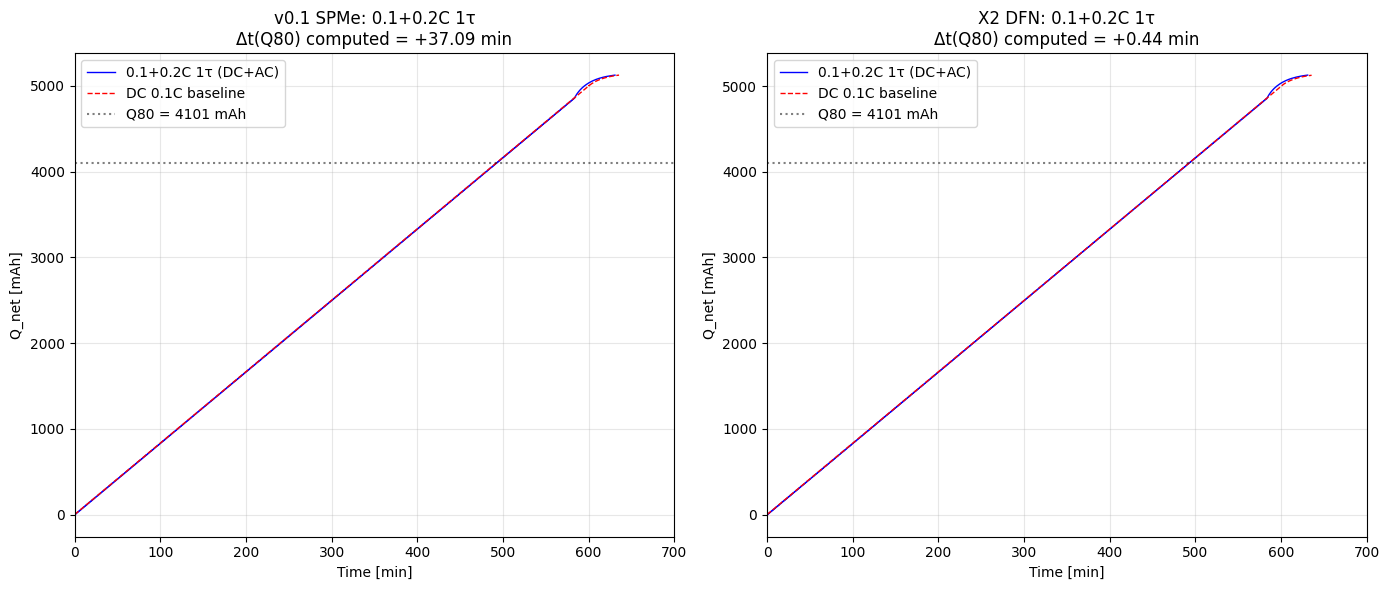


First-passage times to Q80 = 4101 mAh:
v0.1 SPMe protocol: t = 492.64 min
v0.1 SPMe baseline: t = 529.73 min
X2 DFN protocol:    t = 492.63 min
X2 DFN baseline:    t = 493.07 min


In [12]:
# Cell 11: Sanity check — visualize one case to verify Δt(Q80) is correct
import matplotlib.pyplot as plt

# Pick 0.1+0.2C 1τ (SPMe gives Δt = +37 min, looks suspicious)
case_to_check = "0.1+0.2C 1τ"

# Find the case in v0.1 JSON
target_v01 = None
for entry in v01_json:
    if entry.get("condition_label") == case_to_check:
        target_v01 = entry
        break

# Find baseline DC=0.1
target_v01_baseline = v01_baselines[0.1]

# Find the case in X2
target_x2 = None
for r in x2_results_v2:
    if r.get("condition") == case_to_check:
        target_x2 = r
        break
target_x2_baseline = x2_baselines[0.1]

Q80 = 0.80 * 5126.0  # 4101 mAh

# Plot Q(t) for v0.1 SPMe protocol vs SPMe baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: SPMe (v0.1)
ax = axes[0]
t_p = np.array(target_v01["t_chg"]) / 60  # min
Q_p = np.array(target_v01["Q_net_trajectory"])
t_b = target_v01_baseline[0] / 60
Q_b = target_v01_baseline[1]
ax.plot(t_p, Q_p, 'b-', linewidth=1, label=f"{case_to_check} (DC+AC)")
ax.plot(t_b, Q_b, 'r--', linewidth=1, label="DC 0.1C baseline")
ax.axhline(Q80, color='k', linestyle=':', alpha=0.5, label=f"Q80 = {Q80:.0f} mAh")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Q_net [mAh]")
ax.set_title(f"v0.1 SPMe: {case_to_check}\nΔt(Q80) computed = +37.09 min")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 700)

# Panel B: DFN (X2)
ax = axes[1]
t_p_x2 = np.array(target_x2["t_chg"]) / 60
Q_p_x2 = np.array(target_x2["Q_net_trajectory"])
t_b_x2 = target_x2_baseline[0] / 60
Q_b_x2 = target_x2_baseline[1]
ax.plot(t_p_x2, Q_p_x2, 'b-', linewidth=1, label=f"{case_to_check} (DC+AC)")
ax.plot(t_b_x2, Q_b_x2, 'r--', linewidth=1, label="DC 0.1C baseline")
ax.axhline(Q80, color='k', linestyle=':', alpha=0.5, label=f"Q80 = {Q80:.0f} mAh")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Q_net [mAh]")
ax.set_title(f"X2 DFN: {case_to_check}\nΔt(Q80) computed = +0.44 min")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 700)

plt.tight_layout()
plt.show()

# Print first-passage times
def first_passage_time(t, Q, Q_target):
    idx = np.where(np.array(Q) >= Q_target)[0]
    return float(t[int(idx[0])]) / 60 if len(idx) > 0 else np.nan

print(f"\nFirst-passage times to Q80 = {Q80:.0f} mAh:")
print(f"v0.1 SPMe protocol: t = {first_passage_time(target_v01['t_chg'], target_v01['Q_net_trajectory'], Q80):.2f} min")
print(f"v0.1 SPMe baseline: t = {first_passage_time(target_v01_baseline[0], target_v01_baseline[1], Q80):.2f} min")
print(f"X2 DFN protocol:    t = {first_passage_time(target_x2['t_chg'], target_x2['Q_net_trajectory'], Q80):.2f} min")
print(f"X2 DFN baseline:    t = {first_passage_time(target_x2_baseline[0], target_x2_baseline[1], Q80):.2f} min")

Baseline DC 0.1C: where is Q80 reached?

v0.1 SPMe DC 0.1C baseline:
  CC time:    600.48 min
  CV time:    34.95 min
  Total time: 635.43 min
  Q final:    5126 mAh
  t(Q80):     529.73 min
  Q80 reached in: CC phase
  Q at end of CC (t=600.5min): 5004 mAh

X2 DFN DC 0.1C baseline:
  CC time:    600.43 min
  CV time:    35.07 min
  Total time: 635.49 min
  Q final:    5126 mAh
  t(Q80):     493.07 min
  Q80 reached in: CC phase
  Q at end of CC (t=600.4min): 5004 mAh


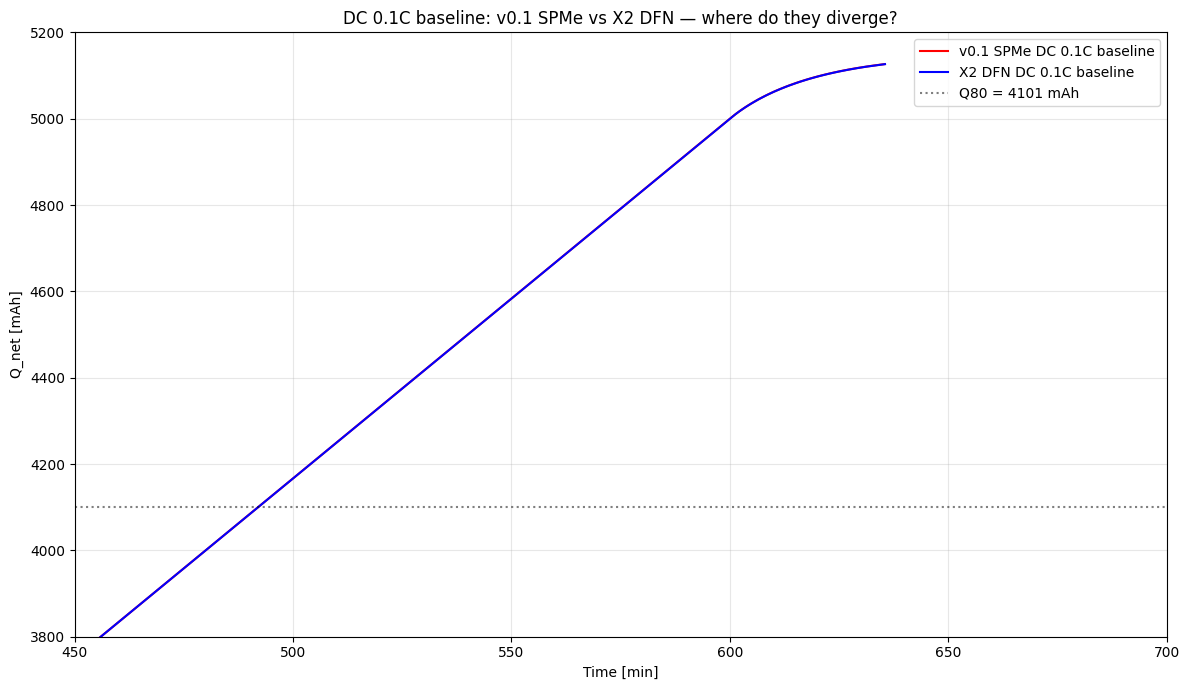

In [13]:
# Cell 12: Diagnose SPMe vs DFN baseline difference
# Look at where Q80 is reached in each baseline
print("=" * 70)
print("Baseline DC 0.1C: where is Q80 reached?")
print("=" * 70)

# v0.1 SPMe baseline (from JSON)
v01_DC01_entry = None
for entry in v01_json:
    if entry["A_Crate"] < 1e-9 and abs(entry["I_DC_Crate"] - 0.1) < 1e-3 and entry["status"] == "ok":
        v01_DC01_entry = entry
        break

if v01_DC01_entry:
    cc_time_min = v01_DC01_entry["CC_time_min"]
    cv_time_min = v01_DC01_entry["CV_time_min"]
    total_min = v01_DC01_entry["total_time_min"]
    Q_final = v01_DC01_entry["Q_net_final_mAh"]
    print(f"\nv0.1 SPMe DC 0.1C baseline:")
    print(f"  CC time:    {cc_time_min:.2f} min")
    print(f"  CV time:    {cv_time_min:.2f} min")
    print(f"  Total time: {total_min:.2f} min")
    print(f"  Q final:    {Q_final:.0f} mAh")
    
    # Where is Q80?
    t_arr = np.array(v01_DC01_entry["t_chg"]) / 60.0
    Q_arr = np.array(v01_DC01_entry["Q_net_trajectory"])
    idx80 = np.where(Q_arr >= 4101)[0][0]
    t80 = t_arr[idx80]
    print(f"  t(Q80):     {t80:.2f} min")
    print(f"  Q80 reached in: {'CC' if t80 < cc_time_min else 'CV'} phase")
    
    # Print Q at end of CC
    idx_cc_end = np.argmin(np.abs(t_arr - cc_time_min))
    Q_at_cc_end = Q_arr[idx_cc_end]
    print(f"  Q at end of CC (t={cc_time_min:.1f}min): {Q_at_cc_end:.0f} mAh")

# DFN baseline (from x2_results_v2)
x2_DC01_entry = None
for r in x2_results_v2:
    if r["A_Crate"] < 1e-9 and abs(r["I_DC_Crate"] - 0.1) < 1e-3 and r["status"] == "ok":
        x2_DC01_entry = r
        break

if x2_DC01_entry:
    cc_time_min = x2_DC01_entry["CC_time_min"]
    cv_time_min = x2_DC01_entry["CV_time_min"]
    total_min = x2_DC01_entry["total_time_min"]
    Q_final = x2_DC01_entry["Q_net_final_mAh"]
    print(f"\nX2 DFN DC 0.1C baseline:")
    print(f"  CC time:    {cc_time_min:.2f} min")
    print(f"  CV time:    {cv_time_min:.2f} min")
    print(f"  Total time: {total_min:.2f} min")
    print(f"  Q final:    {Q_final:.0f} mAh")
    
    t_arr = np.array(x2_DC01_entry["t_chg"]) / 60.0
    Q_arr = np.array(x2_DC01_entry["Q_net_trajectory"])
    idx80 = np.where(Q_arr >= 4101)[0][0]
    t80 = t_arr[idx80]
    print(f"  t(Q80):     {t80:.2f} min")
    print(f"  Q80 reached in: {'CC' if t80 < cc_time_min else 'CV'} phase")
    
    idx_cc_end = np.argmin(np.abs(t_arr - cc_time_min))
    Q_at_cc_end = Q_arr[idx_cc_end]
    print(f"  Q at end of CC (t={cc_time_min:.1f}min): {Q_at_cc_end:.0f} mAh")

# Plot: zoomed-in baseline comparison around Q80
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
t_v01 = np.array(v01_DC01_entry["t_chg"]) / 60.0
Q_v01 = np.array(v01_DC01_entry["Q_net_trajectory"])
t_x2 = np.array(x2_DC01_entry["t_chg"]) / 60.0
Q_x2 = np.array(x2_DC01_entry["Q_net_trajectory"])

ax.plot(t_v01, Q_v01, 'r-', linewidth=1.5, label="v0.1 SPMe DC 0.1C baseline")
ax.plot(t_x2, Q_x2, 'b-', linewidth=1.5, label="X2 DFN DC 0.1C baseline")
ax.axhline(4101, color='k', linestyle=':', alpha=0.5, label="Q80 = 4101 mAh")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Q_net [mAh]")
ax.set_title("DC 0.1C baseline: v0.1 SPMe vs X2 DFN — where do they diverge?")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(450, 700)
ax.set_ylim(3800, 5200)
plt.tight_layout()
plt.show()

In [14]:
# Cell 13: Verify trajectory sampling difference between SPMe and DFN baselines
print("=== SPMe baseline trajectory ===")
t_spme = np.array(v01_DC01_entry["t_chg"])
Q_spme = np.array(v01_DC01_entry["Q_net_trajectory"])
print(f"  Length: {len(t_spme)} samples")
print(f"  Time range: {t_spme.min():.1f} to {t_spme.max():.1f} s ({t_spme.max()/60:.1f} min)")

# Find samples around Q80 = 4101 mAh
mask_near_Q80 = (Q_spme >= 4090) & (Q_spme <= 4115)
print(f"\n  Samples near Q80 (4090-4115 mAh):")
print(f"  Time [min]    Q [mAh]")
for i in np.where(mask_near_Q80)[0][:10]:
    print(f"  {t_spme[i]/60:.3f}      {Q_spme[i]:.2f}")

print("\n=== DFN baseline trajectory ===")
t_dfn = np.array(x2_DC01_entry["t_chg"])
Q_dfn = np.array(x2_DC01_entry["Q_net_trajectory"])
print(f"  Length: {len(t_dfn)} samples")
print(f"  Time range: {t_dfn.min():.1f} to {t_dfn.max():.1f} s ({t_dfn.max()/60:.1f} min)")

mask_near_Q80_dfn = (Q_dfn >= 4090) & (Q_dfn <= 4115)
print(f"\n  Samples near Q80 (4090-4115 mAh):")
print(f"  Time [min]    Q [mAh]")
for i in np.where(mask_near_Q80_dfn)[0][:10]:
    print(f"  {t_dfn[i]/60:.3f}      {Q_dfn[i]:.2f}")

# What's the expected Q80 time analytically?
# 1C charging at DC 0.1C means I = -0.1*5 = -0.5 A (charge)
# Q to reach 80% (4101 mAh = 4.101 Ah): t = Q/|I| = 4.101/0.5 = 8.2 hours = 492 min
print(f"\n=== Analytical expectation ===")
print(f"  At DC 0.1C (I=0.5A): t to reach 4.101 Ah = {4.101/0.5*60:.1f} min")

=== SPMe baseline trajectory ===
  Length: 95 samples
  Time range: 0.0 to 38125.9 s (635.4 min)

  Samples near Q80 (4090-4115 mAh):
  Time [min]    Q [mAh]

=== DFN baseline trajectory ===
  Length: 226 samples
  Time range: 0.0 to 38129.6 s (635.5 min)

  Samples near Q80 (4090-4115 mAh):
  Time [min]    Q [mAh]
  493.071      4108.93

=== Analytical expectation ===
  At DC 0.1C (I=0.5A): t to reach 4.101 Ah = 492.1 min


In [15]:
# Cell 14: Recompute Δt(Q80) with linear interpolation (fix sampling artifact)
import numpy as np
import pandas as pd

def compute_dt_at_Q_interp(t_chg, Q_net_mAh, t_chg_baseline, Q_net_baseline_mAh, Q_target_mAh):
    """First-passage time via LINEAR INTERPOLATION between samples.
       Fixes sparse-sampling artifact in SPMe trajectories."""
    def first_passage_interp(t, Q):
        t = np.asarray(t, dtype=float)
        Q = np.asarray(Q, dtype=float)
        idx = np.where(Q >= Q_target_mAh)[0]
        if len(idx) == 0:
            return np.nan
        i = int(idx[0])
        if i == 0:
            return float(t[0])
        # Linear interpolation between samples i-1 and i
        Q_lo, Q_hi = Q[i-1], Q[i]
        t_lo, t_hi = t[i-1], t[i]
        if Q_hi == Q_lo:
            return float(t_lo)
        frac = (Q_target_mAh - Q_lo) / (Q_hi - Q_lo)
        return float(t_lo + frac * (t_hi - t_lo))
    
    t_proto = first_passage_interp(t_chg, Q_net_mAh)
    t_base = first_passage_interp(t_chg_baseline, Q_net_baseline_mAh)
    if np.isnan(t_proto) or np.isnan(t_base):
        return np.nan
    return (t_base - t_proto) / 60.0   # minutes


Q80_TARGET = 0.80 * 5126.0   # 4101 mAh

# Recompute comparison with interpolation
comparison_rows_v2 = []
for r_x2 in x2_results_v2:
    if r_x2["A_Crate"] < 1e-9:
        continue
    if r_x2.get("status") != "ok":
        continue
    
    DC = float(r_x2["I_DC_Crate"])
    AC = float(r_x2["A_Crate"])
    f = float(r_x2["f_Hz"])
    cond = r_x2["condition"]
    
    v01_match = None
    for entry in v01_json:
        if entry.get("status") != "ok":
            continue
        if entry["A_Crate"] < 1e-9:
            continue
        if abs(float(entry["I_DC_Crate"]) - DC) < 1e-3 and \
           abs(float(entry["A_Crate"]) - AC) < 1e-3 and \
           abs(float(entry["f_Hz"]) - f) < 1e-5:
            v01_match = entry
            break
    
    dt_x2 = np.nan
    if DC in x2_baselines:
        t_base_x2, Q_base_x2 = x2_baselines[DC]
        dt_x2 = compute_dt_at_Q_interp(
            np.array(r_x2["t_chg"]), np.array(r_x2["Q_net_trajectory"]),
            t_base_x2, Q_base_x2, Q80_TARGET,
        )
    
    dt_v01 = np.nan
    if v01_match is not None and DC in v01_baselines:
        t_base_v01, Q_base_v01 = v01_baselines[DC]
        dt_v01 = compute_dt_at_Q_interp(
            np.array(v01_match["t_chg"]), np.array(v01_match["Q_net_trajectory"]),
            t_base_v01, Q_base_v01, Q80_TARGET,
        )
    
    dt_exp = np.nan
    csv_match = df_v01_csv[df_v01_csv["condition"] == cond]
    if len(csv_match) > 0 and pd.notna(csv_match["exp_Δt_Q80"].iloc[0]):
        dt_exp = float(csv_match["exp_Δt_Q80"].iloc[0])
    
    def sign(x):
        if np.isnan(x): return None
        if x > 0.05: return "+"
        if x < -0.05: return "-"
        return "0"
    
    s_x2 = sign(dt_x2)
    s_v01 = sign(dt_v01)
    s_exp = sign(dt_exp)
    
    comparison_rows_v2.append({
        "condition": cond,
        "DC": DC, "AC": AC, "f_Hz": f, "kappa": AC/DC,
        "tau_label": r_x2.get("tau_label", "?"),
        "dt_x2_DFN_min": dt_x2,
        "dt_v01_SPMe_min": dt_v01,
        "dt_exp_MJ1_min": dt_exp,
        "sign_x2": s_x2, "sign_v01": s_v01, "sign_exp": s_exp,
        "x2_vs_exp": (s_x2 == s_exp) if (s_x2 and s_exp) else None,
        "v01_vs_exp": (s_v01 == s_exp) if (s_v01 and s_exp) else None,
        "x2_vs_v01": (s_x2 == s_v01) if (s_x2 and s_v01) else None,
    })

df_compare_v2 = pd.DataFrame(comparison_rows_v2)

display_cols = ["condition", "kappa", "tau_label",
                "dt_x2_DFN_min", "dt_v01_SPMe_min", "dt_exp_MJ1_min",
                "sign_x2", "sign_v01", "sign_exp",
                "x2_vs_exp", "v01_vs_exp", "x2_vs_v01"]

print(f"=== Three-way Δt(Q80) — INTERPOLATED (fixes sampling artifact) ===")
with pd.option_context('display.float_format', '{:+.3f}'.format,
                        'display.width', 200, 'display.max_columns', 20):
    print(df_compare_v2[display_cols].to_string(index=False))

print("\n" + "=" * 70)
print("Sign-agreement statistics (interpolated)")
print("=" * 70)

def agreement_stats(df, col, label):
    valid = df[col].dropna()
    if len(valid) == 0:
        return f"  {label}: no valid comparisons"
    n_agree = int(valid.sum())
    n_valid = len(valid)
    pct = 100.0 * n_agree / n_valid
    return f"  {label}: {n_agree}/{n_valid} ({pct:.1f}%)"

print(agreement_stats(df_compare_v2, "x2_vs_exp", "X2 (DFN) vs MJ1 exp"))
print(agreement_stats(df_compare_v2, "v01_vs_exp", "v0.1 (SPMe) vs MJ1 exp"))
print(agreement_stats(df_compare_v2, "x2_vs_v01", "X2 (DFN) vs v0.1 (SPMe)"))

# Save corrected comparison
df_compare_v2.to_csv("../data/results_day8_x2_three_way_dt_Q80_v2.csv", index=False)
print(f"\nSaved: ../data/results_day8_x2_three_way_dt_Q80_v2.csv")

=== Three-way Δt(Q80) — INTERPOLATED (fixes sampling artifact) ===
     condition  kappa tau_label  dt_x2_DFN_min  dt_v01_SPMe_min  dt_exp_MJ1_min sign_x2 sign_v01 sign_exp  x2_vs_exp  v01_vs_exp  x2_vs_v01
   0.1+0.9C 1τ +9.000        1τ         +0.258           -0.737          +2.880       +        -        +       True       False      False
   0.1+0.2C 1τ +2.000        1τ         -0.528           -0.534          +0.590       -        -        +      False       False       True
   0.2+0.3C 1τ +1.500        1τ         -0.577           -0.536          +0.170       -        -        +      False       False       True
  0.2+0.3C 10τ +1.500       10τ         -5.296           -5.315          +5.050       -        -        +      False       False       True
0.2+0.3C 34.8τ +1.500     34.8τ         -1.395          -18.816         +15.030       -        -        +      False       False       True
 0.2+0.8C 0.1τ +4.000      0.1τ         -0.092           -0.075          +1.260       -      